In [5]:
from google.colab import files

uploaded = files.upload()


Saving store_customers.csv to store_customers.csv


In [6]:
import pandas as pd

df = pd.read_csv("store_customers.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0        1000      M  39.0                59.9                    58.0
1        1001      M  34.0                48.4                    37.0
2        1002      F  40.0                70.5                    26.0
3        1003      F  47.0                81.1                    30.0
4        1004      F  33.0                42.1                    58.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB
None
CustomerID                0
Ge

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Annual Income (k$)"] = df["Annual Income (k$)"].fillna(
    df["Annual Income (k$)"].median()
)

df["Spending Score (1-100)"] = df["Spending Score (1-100)"].fillna(
    df["Spending Score (1-100)"].median()
)

df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic statistics
print(df.describe())

        CustomerID          Age  Annual Income (k$)  Spending Score (1-100)
count  1000.000000  1000.000000         1000.000000             1000.000000
mean   1499.500000    38.918000           57.116500               42.672000
std     288.819436    13.361505           28.575769               20.043956
min    1000.000000    18.000000           15.000000                1.000000
25%    1249.750000    30.000000           35.075000               31.750000
50%    1499.500000    36.000000           49.000000               47.000000
75%    1749.250000    44.000000           79.325000               57.000000
max    1999.000000    80.000000          144.100000               92.000000


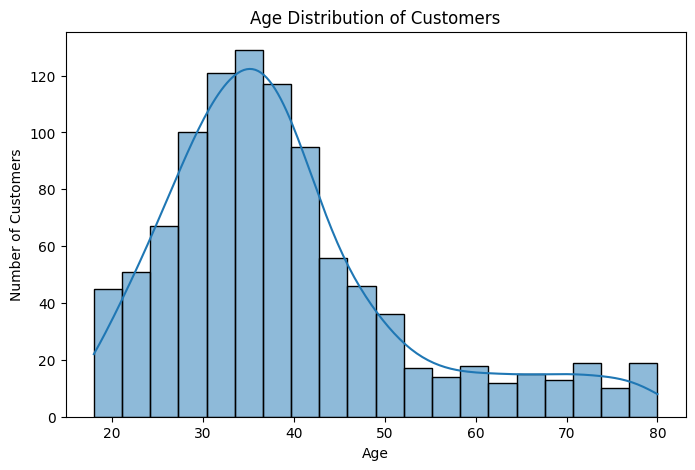

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

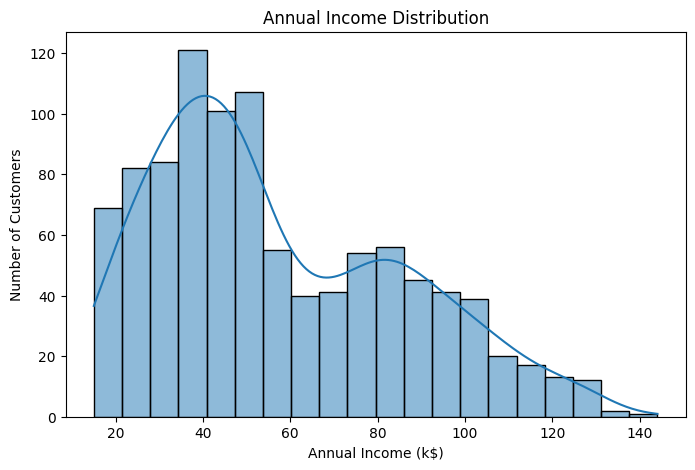

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.show()

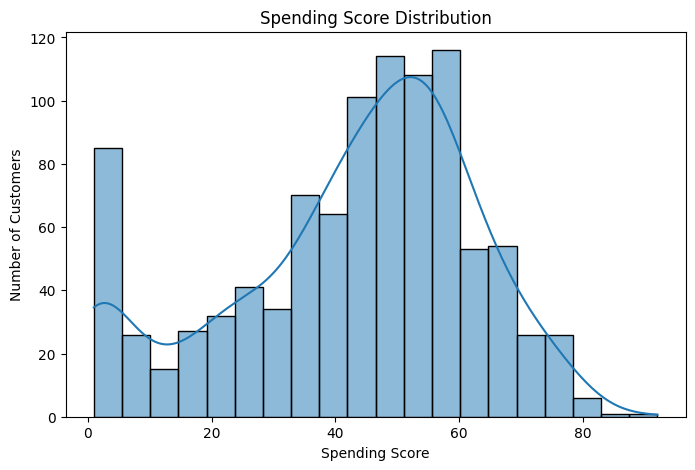

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.show()

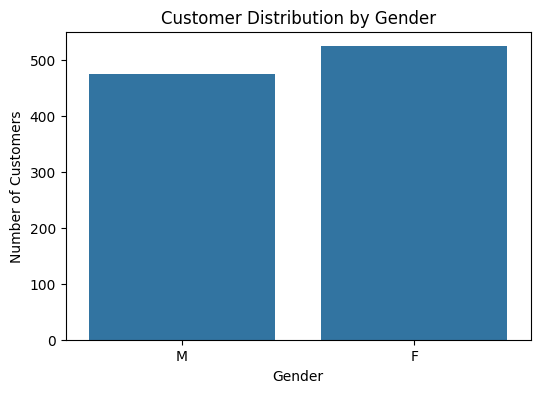

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender")
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

In [14]:
features = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

print(features.head())

    Age  Annual Income (k$)  Spending Score (1-100)
0  39.0                59.9                    58.0
1  34.0                48.4                    37.0
2  40.0                70.5                    26.0
3  47.0                81.1                    30.0
4  33.0                42.1                    58.0


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

print(X_scaled[:5])

[[ 0.0061401   0.09745644  0.76510194]
 [-0.36825649 -0.3051838  -0.28311966]
 [ 0.08101942  0.46858571 -0.83218813]
 [ 0.60517466  0.83971497 -0.63252687]
 [-0.44313581 -0.52576062  0.76510194]]


In [19]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


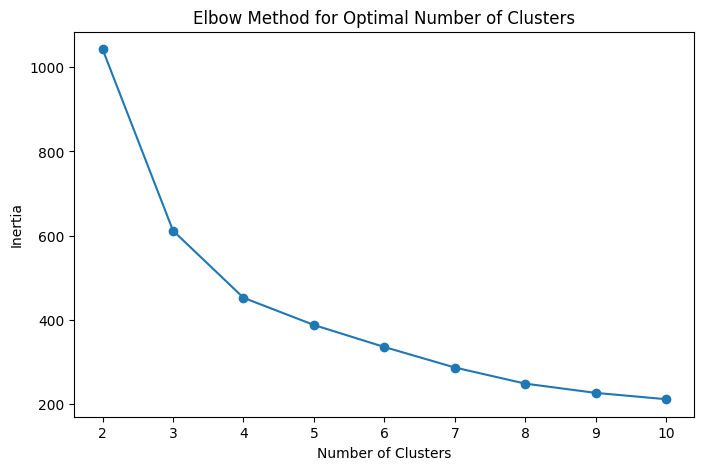

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.show()

In [21]:
from sklearn.cluster import KMeans

# Create K-Means model with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Assign each customer to a cluster
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Display the first few rows
print(df.head())

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)  \
0        1000      M  39.0                59.9                    58.0   
1        1001      M  34.0                48.4                    37.0   
2        1002      F  40.0                70.5                    26.0   
3        1003      F  47.0                81.1                    30.0   
4        1004      F  33.0                42.1                    58.0   

   Cluster  
0        1  
1        1  
2        2  
3        2  
4        1  


In [22]:
cluster_summary = df.groupby("Cluster").agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean",
    "CustomerID": "count"
}).round(2)

cluster_summary = cluster_summary.rename(
    columns={"CustomerID": "Customer Count"}
)

print(cluster_summary)

           Age  Annual Income (k$)  Spending Score (1-100)  Customer Count
Cluster                                                                   
0        66.70              107.58                    4.98             128
1        35.55               49.42                   47.68             333
2        45.14               81.16                   30.34             212
3        27.44               29.61                   60.32             327


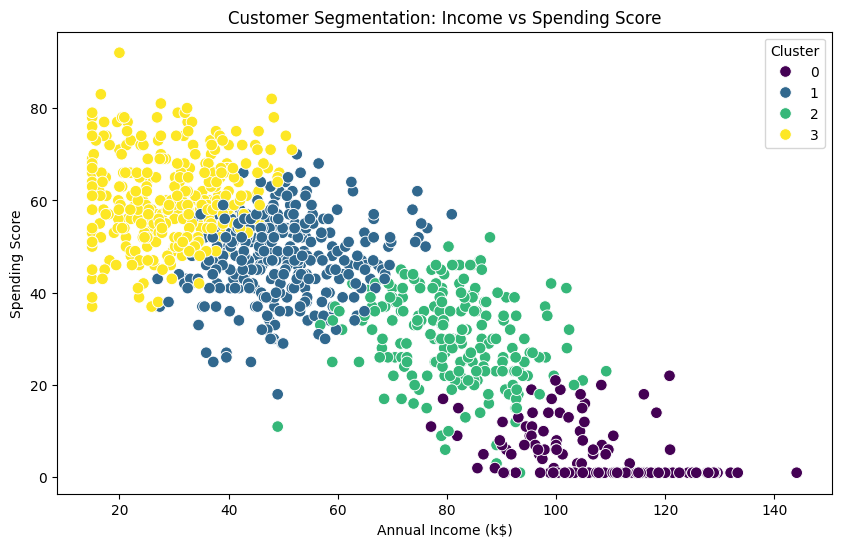

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segmentation: Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend(title="Cluster")
plt.show()

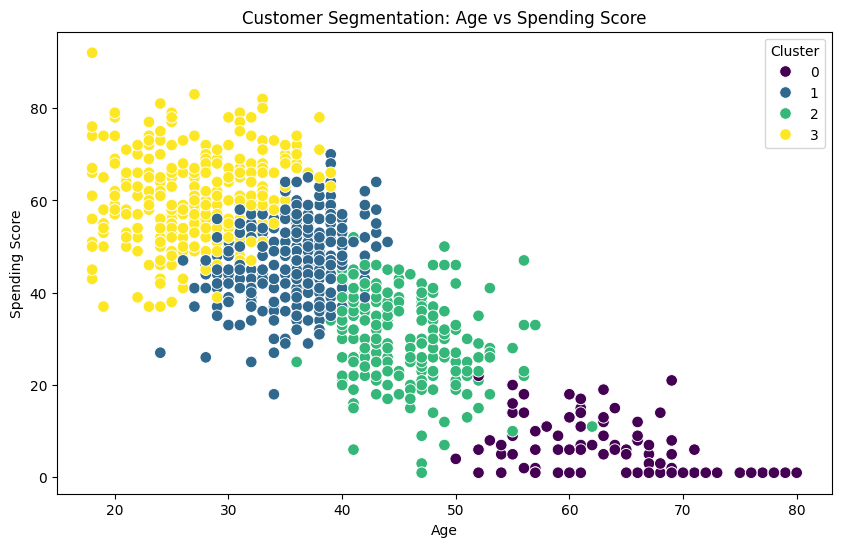

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segmentation: Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.legend(title="Cluster")
plt.show()

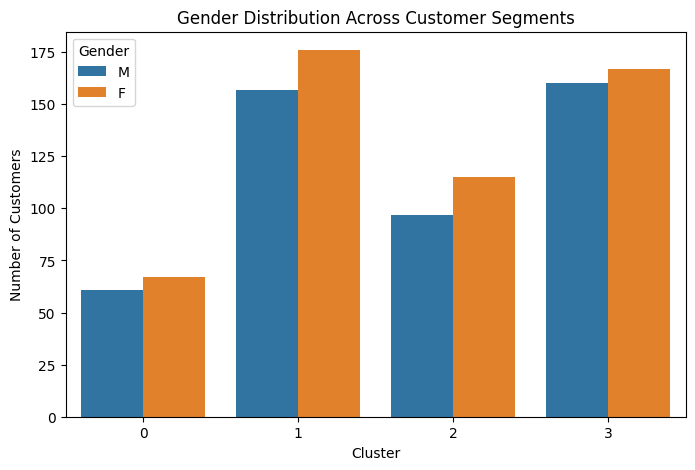

In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Cluster",
    hue="Gender"
)

plt.title("Gender Distribution Across Customer Segments")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

In [27]:
segment_names = {
    0: "High-Income Low-Spending",
    1: "Moderate Customers",
    2: "Affluent Low-Engagement",
    3: "Young Active Spenders"
}

df["Customer Segment"] = df["Cluster"].map(segment_names)

print(df.head())

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)  \
0        1000      M  39.0                59.9                    58.0   
1        1001      M  34.0                48.4                    37.0   
2        1002      F  40.0                70.5                    26.0   
3        1003      F  47.0                81.1                    30.0   
4        1004      F  33.0                42.1                    58.0   

   Cluster         Customer Segment  
0        1       Moderate Customers  
1        1       Moderate Customers  
2        2  Affluent Low-Engagement  
3        2  Affluent Low-Engagement  
4        1       Moderate Customers  


In [28]:
segment_summary = df.groupby("Customer Segment").agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean",
    "CustomerID": "count"
}).round(2)

segment_summary = segment_summary.rename(
    columns={"CustomerID": "Customer Count"}
)

print(segment_summary)

                            Age  Annual Income (k$)  Spending Score (1-100)  \
Customer Segment                                                              
Affluent Low-Engagement   45.14               81.16                   30.34   
High-Income Low-Spending  66.70              107.58                    4.98   
Moderate Customers        35.55               49.42                   47.68   
Young Active Spenders     27.44               29.61                   60.32   

                          Customer Count  
Customer Segment                          
Affluent Low-Engagement              212  
High-Income Low-Spending             128  
Moderate Customers                   333  
Young Active Spenders                327  


In [30]:
df.to_csv("customer_segmentation_final.csv", index=False)

print("Customer segmentation file saved successfully!")

Customer segmentation file saved successfully!


In [31]:
from google.colab import files

files.download("customer_segmentation_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>